In [1]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
#Loading Datasets

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
gender_df = pd.read_csv("gender_submission.csv")

In [3]:
#View First Rows (Training Dataset - Used in this EDA)

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Dataset Shape

print(train_df.shape)

(891, 12)


In [5]:
#Dataset Information

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
#Summary Statistics

train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#Finding Missing Values

train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
#Check Duplicate Rows

train_df.duplicated().sum()

np.int64(0)

In [9]:
#Analyzing the target variable, that is, Survival Count
#(0 - Did not Survived; 1 - Survived)

train_df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [10]:
#Calculate Survival Percentage

(train_df["Survived"].value_counts(normalize=True) * 100).round(2)

,proportion
Survived,
0,61.62
1,38.38


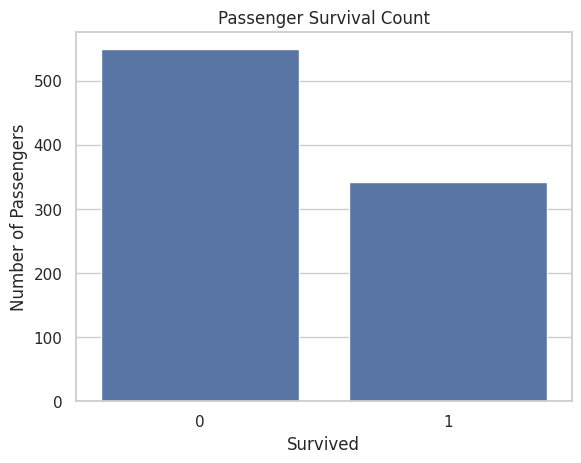

In [11]:
#Visualize the Survival Results

sns.countplot(x="Survived", data=train_df)

plt.title("Passenger Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

In [12]:
#Gender Distribution Analysis

train_df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [13]:
#Calculating Percentage Distribution of Sex

(train_df["Sex"].value_counts(normalize=True) * 100).round(2)

,proportion
Sex,
male,64.76
female,35.24


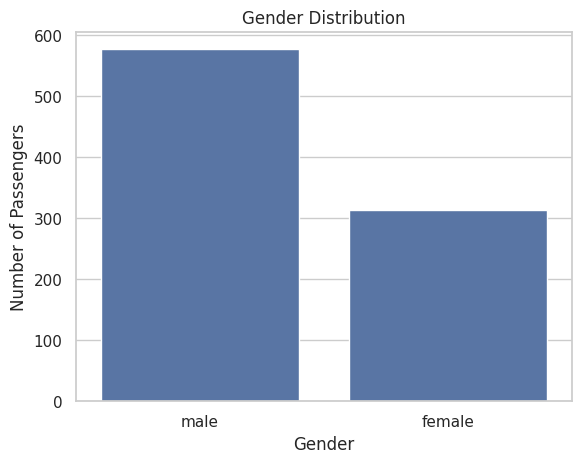

In [14]:
#Visualize Gender Distribution

sns.countplot(x="Sex", data=train_df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

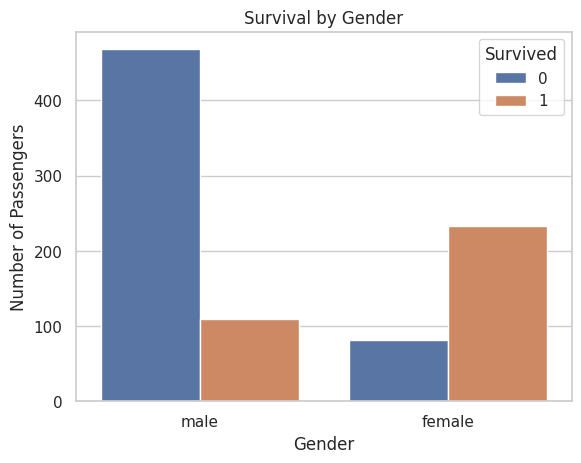

In [15]:
#Survival Analysis by Gender

sns.countplot(x="Sex", hue="Survived", data=train_df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

In [16]:
#Calculating Survival Rate by Gender

train_df.groupby("Sex")["Survived"].mean()*100

,Survived
Sex,
female,74.203822
male,18.890815


In [17]:
#Passenger Class Distribution Analysis

train_df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [18]:
#Calculating Percentage Distribution of Passenger Class

(train_df["Pclass"].value_counts(normalize=True) * 100).round(2)

,proportion
Pclass,
3,55.11
1,24.24
2,20.65


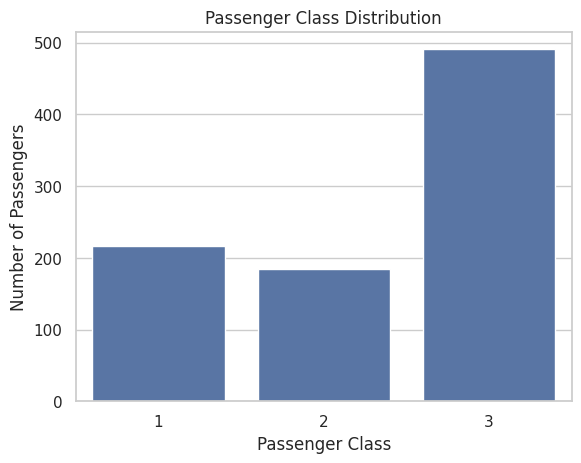

In [19]:
#Visualizing the Percentage Class Distribution

sns.countplot(x="Pclass", data=train_df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

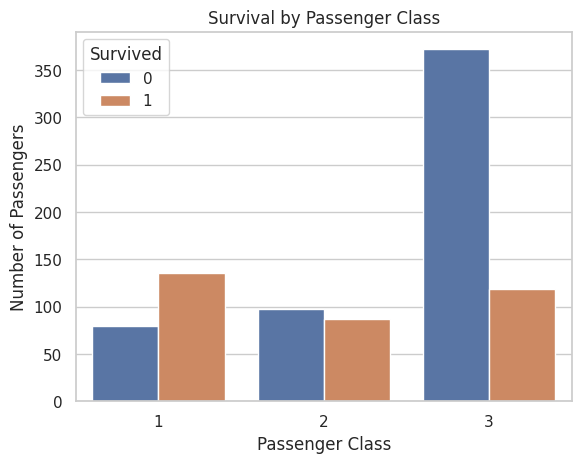

In [20]:
#Survival Analysis by Passenger Class

sns.countplot(x="Pclass", hue="Survived", data=train_df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

In [21]:
##Calculating Survival Rate by Passenger Class

(train_df.groupby("Pclass")["Survived"].mean()*100).round(2)

,Survived
Pclass,
1,62.96
2,47.28
3,24.24


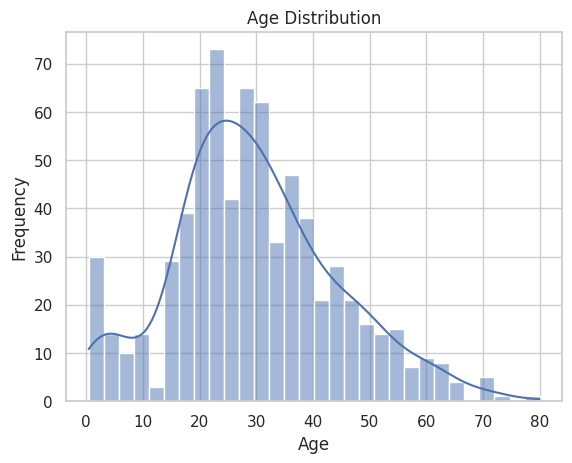

In [22]:
#Age Distribution Analysis (Histogram)

sns.histplot(train_df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [23]:
#Verify with Statistics

train_df["Age"].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [24]:
#Additional Insight

train_df["Age"].mode()

,Age
0,24.0


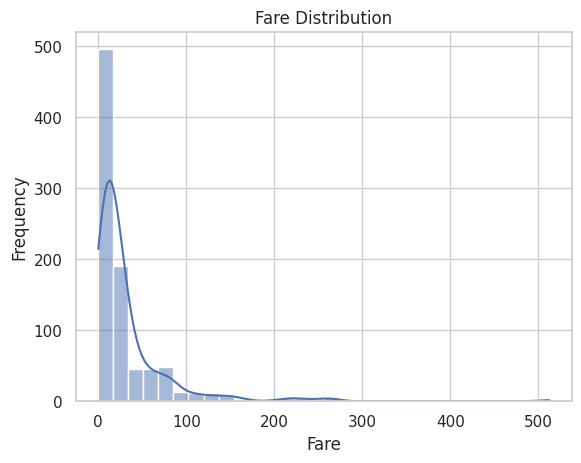

In [25]:
#Fare Distribution Analysis (Histogram)

sns.histplot(train_df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

In [26]:
#Verify with Statistics

train_df["Fare"].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [27]:
#Additional Insight

train_df["Fare"].max()

512.3292

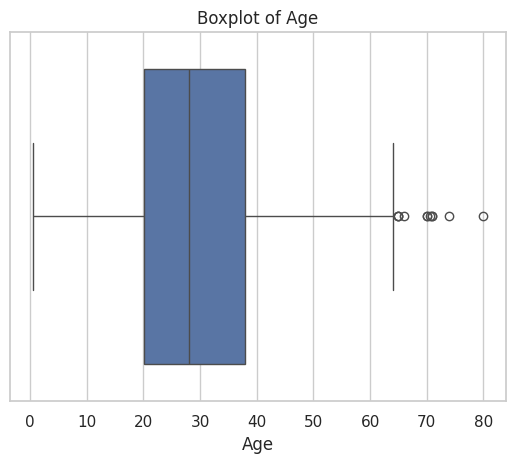

In [28]:
#Age Distribution using Boxplot

sns.boxplot(x=train_df["Age"])

plt.title("Boxplot of Age")
plt.xlabel("Age")

plt.show()

In [29]:
#Verify with Statistics

train_df["Age"].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


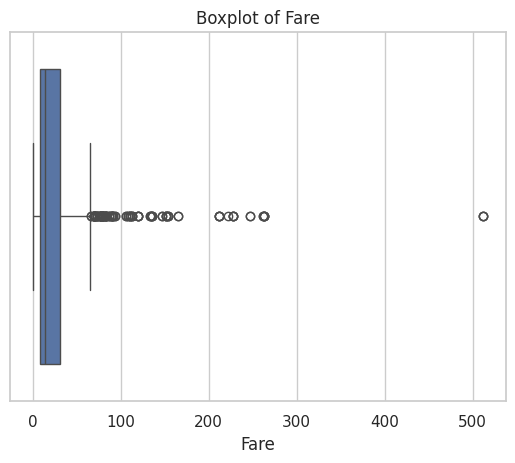

In [30]:
#Fare Distribution using Boxplot

sns.boxplot(x=train_df["Fare"])

plt.title("Boxplot of Fare")
plt.xlabel("Fare")

plt.show()

In [31]:
#Verify with Statistics

train_df["Fare"].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [32]:
#Embarked (Port of Embarkation) Analysis

train_df["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [33]:
#Percentage Distribution of Embarked (Port of Embarkation)

(train_df["Embarked"].value_counts(normalize=True) * 100).round(2)

,proportion
Embarked,
S,72.44
C,18.90
Q,8.66


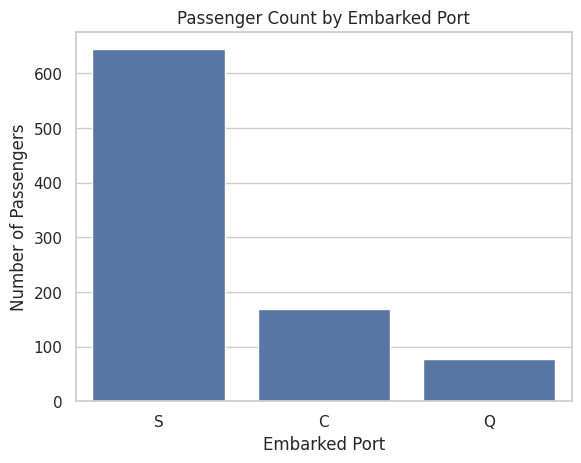

In [34]:
#Visualize Embarked Distribution

sns.countplot(x="Embarked", data=train_df)

plt.title("Passenger Count by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Number of Passengers")

plt.show()

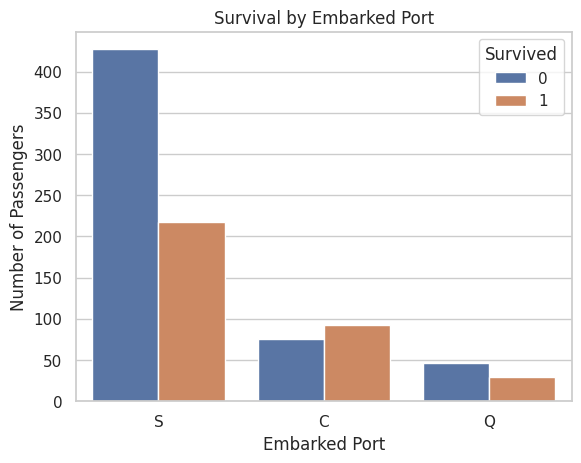

In [35]:
#Survival Analysis by Embarkation Port

sns.countplot(x="Embarked", hue="Survived", data=train_df)

plt.title("Survival by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Number of Passengers")

plt.show()

In [36]:
#Calculate Survival Rate by Port

(train_df.groupby("Embarked")["Survived"].mean()*100).round(2)

,Survived
Embarked,
C,55.36
Q,38.96
S,33.70


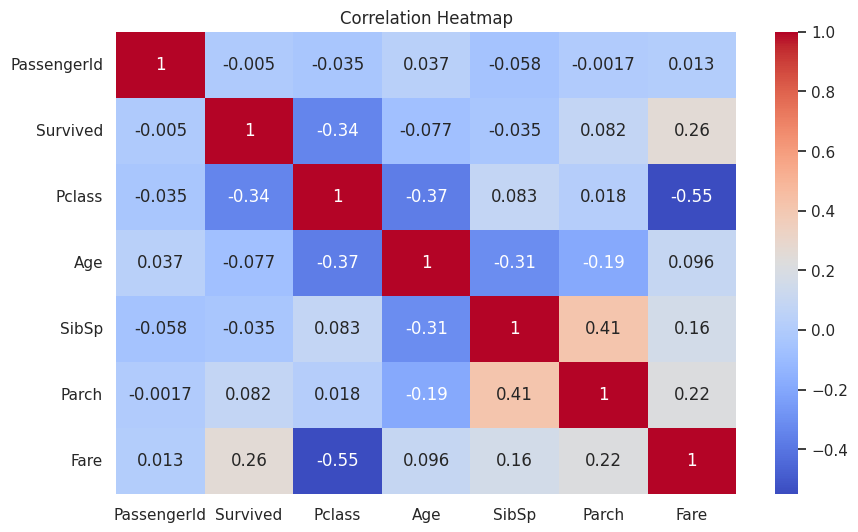

In [37]:
#Correlation Heatmap

numeric_df = train_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

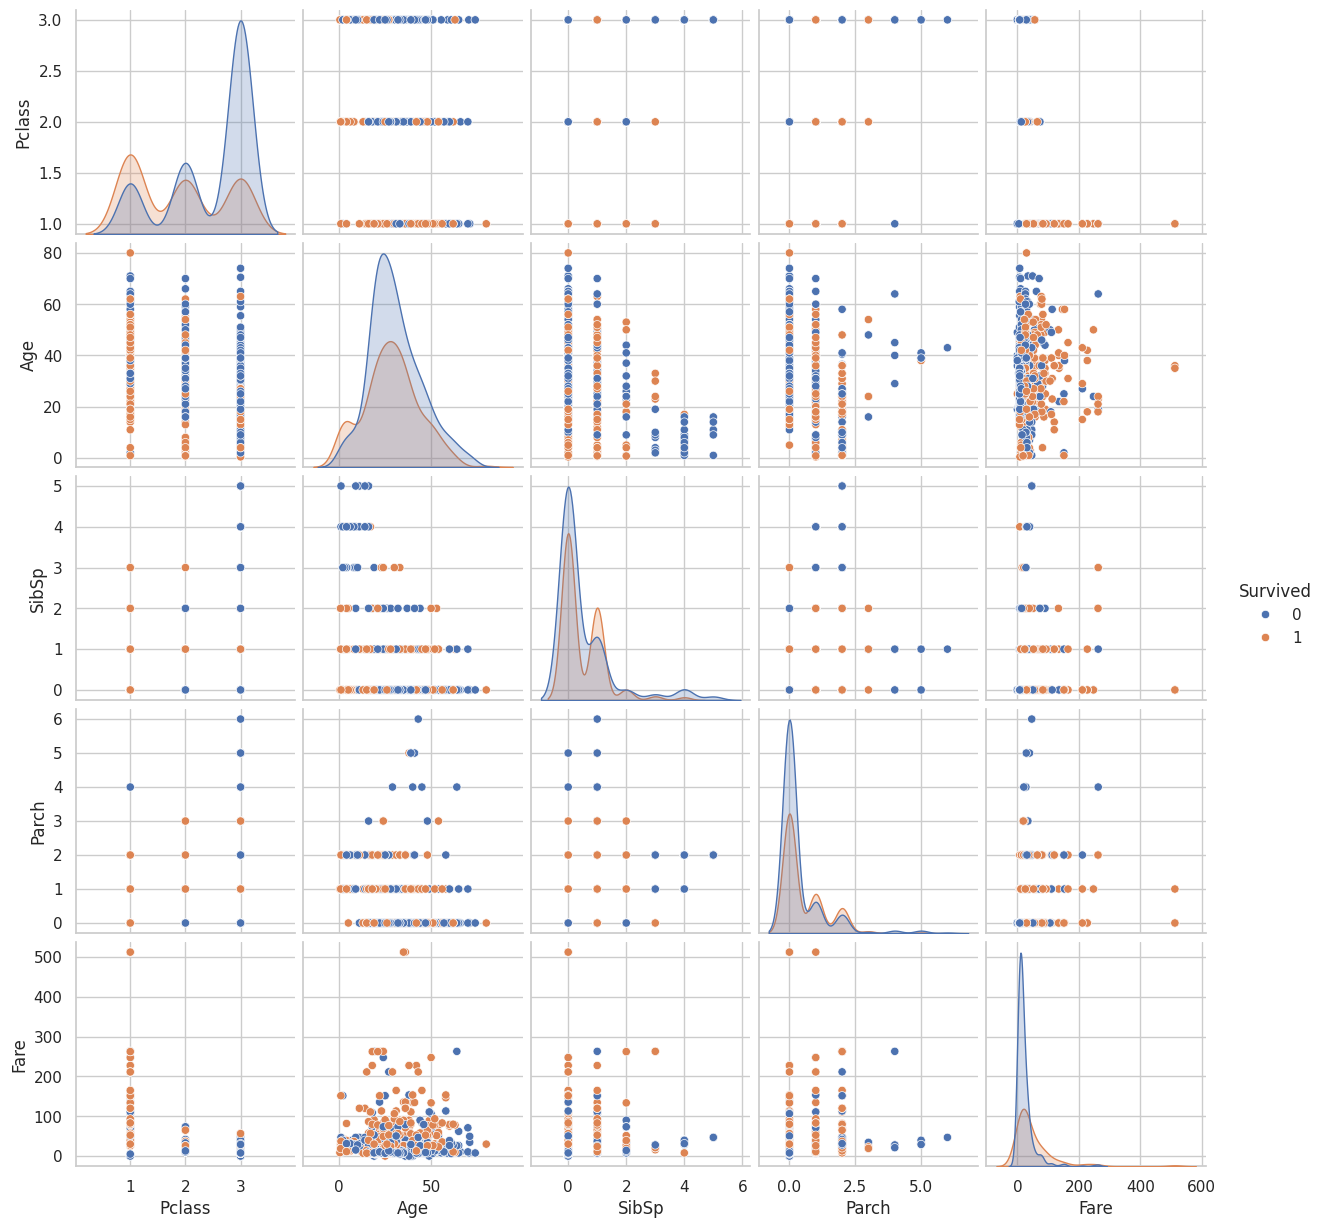

In [38]:
#Pairplot (Multivariate Analysis)

sns.pairplot(
    train_df[
        ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
    ].dropna(),
    hue="Survived"
)

plt.show()

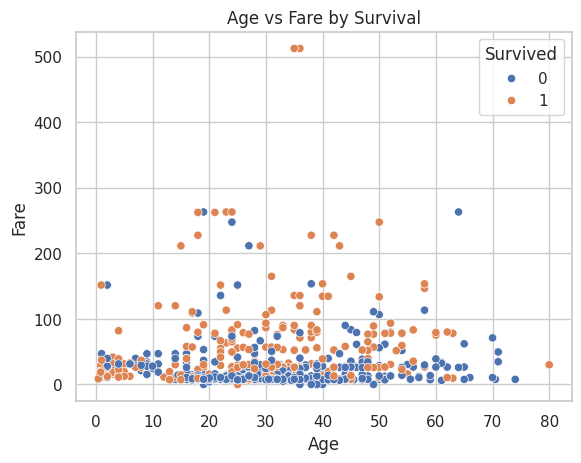

In [39]:
#Scatter Plot (Age vs Fare by Survival)

sns.scatterplot(
    x="Age",
    y="Fare",
    hue="Survived",
    data=train_df
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [40]:
#Survival Rate by Gender

train_df.groupby("Sex")["Survived"].mean() * 100

,Survived
Sex,
female,74.203822
male,18.890815


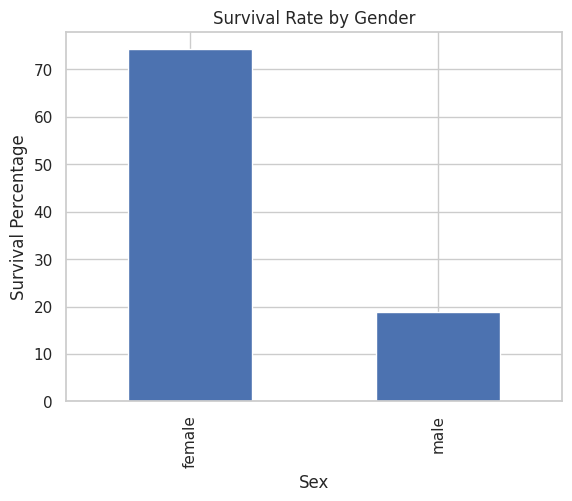

In [43]:
#Visualizing the Survival Rate by Gender

(train_df.groupby("Sex")["Survived"].mean() * 100).plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Percentage")
plt.show()

In [44]:
#Survival Rate by Passenger Class

train_df.groupby("Pclass")["Survived"].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


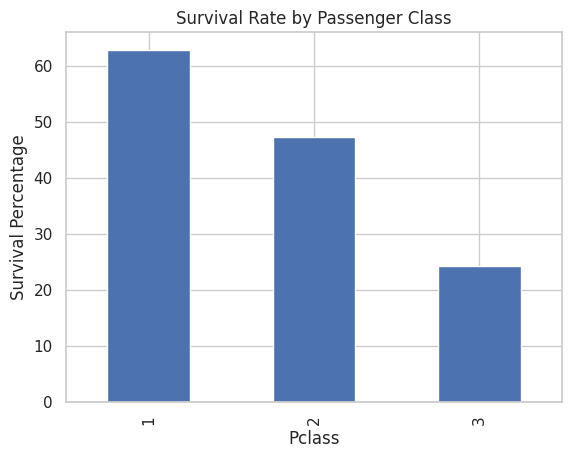

In [45]:
#Visualizing the Survival Rate by Passenger Class

(train_df.groupby("Pclass")["Survived"].mean() * 100).plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Percentage")
plt.show()

In [46]:
#Final Summary of Findings

print("""
Summary of Findings:

1. Female passengers had a much higher survival rate than male passengers.

2. First-Class passengers had significantly better survival chances than Second-Class and Third-Class passengers.

3. Most passengers were young adults between 20 and 40 years of age.

4. The Fare column is highly right-skewed and contains several outliers.

5. The Age column contains missing values, while the Cabin column has a large number of missing entries.

6. Passenger Class and Fare show the strongest relationship with survival.

7. Passengers paying higher fares were generally more likely to survive.

8. Southampton was the primary embarkation port, accounting for the majority of passengers.

9. Age showed a relatively weak relationship with survival compared to Passenger Class and Fare.

10. Exploratory Data Analysis helped identify important patterns, trends, correlations, missing values, and outliers in the Titanic dataset.
""")


Summary of Findings:

1. Female passengers had a much higher survival rate than male passengers.

2. First-Class passengers had significantly better survival chances than Second-Class and Third-Class passengers.

3. Most passengers were young adults between 20 and 40 years of age.

4. The Fare column is highly right-skewed and contains several outliers.

5. The Age column contains missing values, while the Cabin column has a large number of missing entries.

6. Passenger Class and Fare show the strongest relationship with survival.

7. Passengers paying higher fares were generally more likely to survive.

8. Southampton was the primary embarkation port, accounting for the majority of passengers.

9. Age showed a relatively weak relationship with survival compared to Passenger Class and Fare.

10. Exploratory Data Analysis helped identify important patterns, trends, correlations, missing values, and outliers in the Titanic dataset.



# Interview Questions and Answers

## 1. What is Exploratory Data Analysis (EDA) and why is it important?

### Answer

Exploratory Data Analysis (EDA) is the process of examining and understanding a dataset using statistical summaries and visualizations before applying machine learning or advanced analysis techniques.

EDA is important because it helps:

- Understand the structure of the data
- Identify missing values and outliers
- Discover patterns and trends
- Detect relationships between variables
- Improve data quality before modeling

In this project, EDA helped uncover important factors affecting passenger survival on the Titanic.

---

## 2. Which plots do you use to check correlation?

### Answer

The most commonly used plots for checking correlation are:

- **Heatmap** – Shows correlation coefficients between numerical variables.
- **Scatter Plot** – Visualizes the relationship between two numerical variables.
- **Pairplot** – Displays relationships among multiple numerical variables simultaneously.

In this project, a Heatmap and Pairplot were used to analyze correlations among Titanic features.

---

## 3. How do you handle skewed data?

### Answer

Skewed data can be handled using several techniques:

- Log Transformation
- Square Root Transformation
- Box-Cox Transformation
- Outlier Treatment
- Feature Scaling

In the Titanic dataset, the Fare column was positively skewed because a few passengers paid very high ticket fares.

---

## 4. How do you detect multicollinearity?

### Answer

Multicollinearity occurs when independent variables are highly correlated with each other.

Common methods to detect multicollinearity include:

- Correlation Matrix
- Heatmap
- Variance Inflation Factor (VIF)
- Pairplot Analysis

In this project, the Heatmap was used to identify relationships between numerical variables.

---

## 5. What are Univariate, Bivariate, and Multivariate Analyses?

### Answer

### Univariate Analysis

Analysis of a single variable.

**Examples:**
- Age Distribution Histogram
- Fare Boxplot

### Bivariate Analysis

Analysis of two variables to study their relationship.

**Examples:**
- Survival by Gender
- Age vs Fare Scatter Plot

### Multivariate Analysis

Analysis involving more than two variables simultaneously.

**Examples:**
- Pairplot
- Correlation Heatmap

---

## 6. What is the Difference Between a Heatmap and a Pairplot?

### Answer

| Heatmap | Pairplot |
|----------|----------|
| Shows correlation values numerically | Shows actual graphical relationships |
| Easier to identify correlation strength | Easier to visualize trends and clusters |
| Works mainly with numerical variables | Displays scatterplots and distributions |
| Provides summarized relationships | Provides detailed visual relationships |

In this project, both Heatmap and Pairplot were used to understand feature relationships.

---

## 7. How Do You Summarize Your Insights?

### Answer

Insights are summarized by:

1. Identifying important trends and patterns.
2. Highlighting key relationships between variables.
3. Reporting missing values and outliers.
4. Explaining significant visualizations.
5. Providing business or analytical conclusions.

### Key Findings from the Titanic Dataset

- Female passengers had a significantly higher survival rate than male passengers.
- First-Class passengers had better survival chances than Third-Class passengers.
- Fare showed a positive relationship with survival.
- Age had a relatively weak relationship with survival.
- The Fare column was highly right-skewed and contained outliers.
- Missing values were present in Age, Cabin, and Embarked columns.
- Passenger Class and Fare were among the most influential factors affecting survival.

### Conclusion

These insights demonstrate how Exploratory Data Analysis (EDA) can be used to uncover meaningful patterns, identify data quality issues, understand variable relationships, and support data-driven decision-making.